# DRUG CLASSIFICATION

Задача: предсказать какое лекарство стоит назначить конкретному пациенту

Польза: индивидуальное назначение лекарств пациентам на основе их личных данных

СПРАВКА:
BP - уровни артериального давления  
Cholesterol - уровень холестерина  
Na_to_K - отношение натрия и калия в организме человека.

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prathamtripathi/drug-classification")

print("Path to dataset files:", path)

100%|██████████| 1.68k/1.68k [00:00<00:00, 453kB/s]

Extracting files...
Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\prathamtripathi\drug-classification\versions\1


In [4]:
df = pd.read_csv("drug200.csv")

In [5]:
df.head(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [6]:
df['Drug'].unique()

<ArrowStringArray>
['DrugY', 'drugC', 'drugX', 'drugA', 'drugB']
Length: 5, dtype: str

В датасете имеются различные виды лекарств групп A,B,C,X,Y

---

In [10]:
print("===МИНИМАЛЬНОЕ ОТНОШЕНИЕ===")
print(np.min(df['Na_to_K']))
print("\n===СРЕДНЕЕ ОТНОШЕНИЕ===")
print(np.mean(df['Na_to_K']))
print("\n===МАКСИМАЛЬНОЕ ОТНОШЕНИЕ===")
print(np.max(df['Na_to_K']))

===МИНИМАЛЬНОЕ ОТНОШЕНИЕ===
6.269

===СРЕДНЕЕ ОТНОШЕНИЕ===
16.084485

===МАКСИМАЛЬНОЕ ОТНОШЕНИЕ===
38.247


---


In [14]:
print("===МИНИМАЛЬНЫЙ ВОЗРАСТ===")
print(np.min(df['Age']))
print("\n===СРЕДНИЙ ВОЗРАСТ===")
print(np.median(df['Age']))
print("\n===МАКСИМАЛЬНЫЙ ВОЗРАСТ===")
print(np.max(df['Age']))
print()
print(df['Sex'].value_counts())

===МИНИМАЛЬНЫЙ ВОЗРАСТ===
15

===СРЕДНИЙ ВОЗРАСТ===
45.0

===МАКСИМАЛЬНЫЙ ВОЗРАСТ===
74

Sex
M    104
F     96
Name: count, dtype: int64


Соотношение мужского и женского пола равномерно
Возраст людей в выборке крайне различен с большим уклоном в взрослых и пожилых людей

DrugX и DrugY имеют слишком большой перекос в датафрейме, потому проводить анализ на основе сумм не стоит

---

In [48]:
print(df['BP'].value_counts())
print()
print(df['Cholesterol'].value_counts())
print()
print(df['Drug'].value_counts())

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


---

### По первичному осмотру можно выявить, что в датасете собраны данные о различных пациентах с равномерным количеством людей для каждого признака
Большинство данных являются категориальными, но также имеются количественные данные о возрасте и соотношении натрия к калию в организме человека

---

In [18]:
# Проверка на пропуски

df.isnull().sum().sum()

np.int64(0)

В данном датасете отсутствуют пропуски

---

Text(0.5, 1.0, 'Na_to_K по типам лекарств')

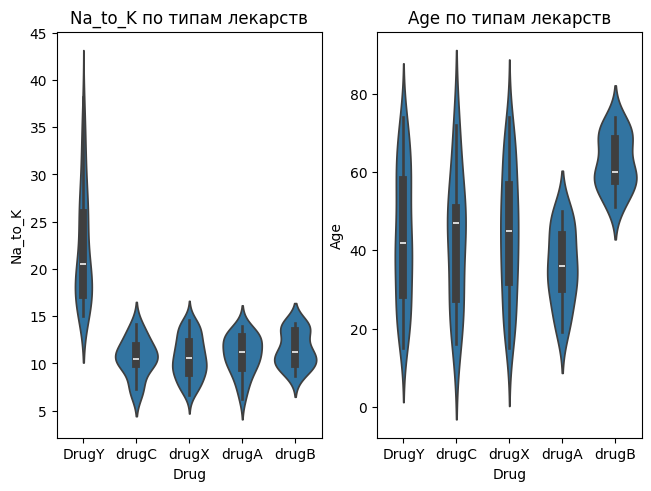

In [51]:
fig, axs = plt.subplots(1, 2, layout='constrained')
# Здесь можно еще боксплот выбрать, но виолин выглядит прикольнее
sns.violinplot(data=df, x="Drug", y="Age", ax=axs[1])
axs[1].set_title("Age по типам лекарств")

sns.violinplot(data=df, x="Drug", y="Na_to_K", ax=axs[0])
axs[0].set_title("Na_to_K по типам лекарств")

### Выше мы рассмотрели количественные признаки
У людей с большим количеством натрия по отношению к калию(na_to_k > 15), наиболее вероятно назначается лекарство DrugY

На соседнем графике можно заметить что для молодых людей наиболее часто назначается drugA, а для пожилых людей назначается drugB

Text(0.5, 1.0, 'Холестирин по типам лекарств')

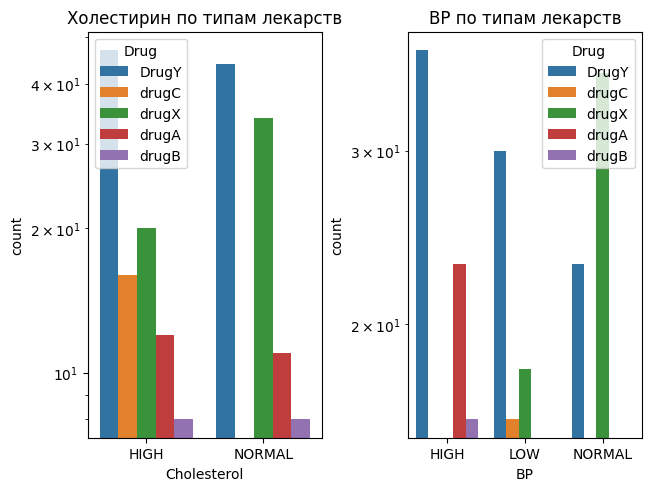

In [54]:
fig, axs = plt.subplots(1, 2, layout='constrained')

sns.countplot(data=df, x="BP", hue="Drug", ax=axs[1])
axs[1].set_yscale('log')
axs[1].set_title("BP по типам лекарств")

sns.countplot(data=df, x="Cholesterol", hue="Drug", ax=axs[0])
axs[0].set_yscale('log')
axs[0].set_title("Холестирин по типам лекарств")

### Генеральные наблюдения на категориальных данных

Лекарства A и B встречаются ТОЛЬКО при высоком уровне артериального давления  
Лекарство C назначается ТОЛЬКО при малом уровне артериального давления

Лекарство C назначается ТОЛЬКо при высоком уровне холестирина

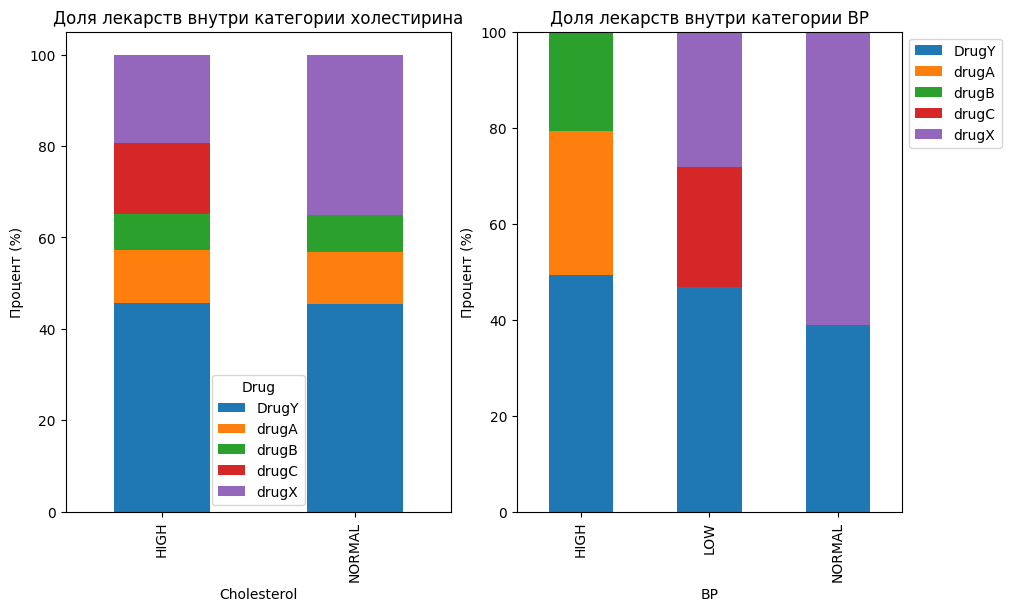

In [75]:
fig, axs = plt.subplots(1, 2, layout='constrained')

ch_dist = pd.crosstab(df['Cholesterol'], df['Drug'], normalize='index') * 100

ch_dist.plot(kind='bar', stacked=True, figsize=(10, 6), ax=axs[0])
axs[0].set_title("Доля лекарств внутри категории холестирина")
axs[0].set_ylabel("Процент (%)")

bp_dist = pd.crosstab(df['BP'], df['Drug'], normalize='index') * 100

bp_dist.plot(kind='bar', stacked=True, figsize=(10, 6), ax=axs[1])
axs[1].set_title("Доля лекарств внутри категории BP")
axs[1].set_ylabel("Процент (%)")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

Тут раннее выявленные правила выражены более отчетливо  
DrugY не зависит от холестирина или артериального давления, ему важен лишь Na_to_K  
При нормальном артериальном давлении и Na_to_K ниже 15, назначается drugX

---

### Выводы после генерального анализа
DrugY имеет сильный перевес в датасете, однако выравнивать значения не имеет смысла, потому что данное лекарство назначается только при Na_to_K выше 15.  
Некоторые лекарства не появляются при различных значениях артериального давления или холестирина.

---


### Кодировка

HIGH, LOW, Normal при LabelEncoding будет кодироваться неправильно  
Будет сделан маппинг значений вручную, чтобы избежать путаницы  
Для Drug будет использован простой LabelEncoding


In [90]:
# Проводим кодировку
le = LabelEncoder()
df['Drug'] = le.fit_transform(df['Drug'])

df['BP'] = df['BP'].map({"LOW": 0, "NORMAL": 1, "HIGH": 2})
df['Cholesterol'] = df['Cholesterol'].map({'NORMAL': 0, 'HIGH': 1})
df['Sex'] = df['Sex'].map({'M': 0, 'F': 1})

In [91]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,2,1,25.355,0
1,47,0,0,1,13.093,3
2,47,0,0,1,10.114,3
3,28,1,1,1,7.798,4
4,61,1,0,1,18.043,0


---

### Тренировка модели

Данных немного, однако правила явные и для них большая глубина не понадобится  

In [99]:
X = df.drop('Drug', axis=1)
y = df['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [105]:
baseline = df['Drug'].value_counts(normalize=True).max()
print(f"Baseline Accuracy: {baseline:.2%}")

Baseline Accuracy: 45.50%


In [103]:
clf = DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [106]:
acscore = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accurasy: {acscore:.2%}")

Decision Tree Accurasy: 97.50%


Моя модель справилась 😎😎😎